<a href="https://colab.research.google.com/github/Vanisha-18/AIML_Projects-Labs/blob/main/Copy_of_AIML_Module_4_Lab_2_Introduction_to_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Module 4: Perceptron and Gradient Descent**
## Lab 2: Introduction to Gradient Descent

Understanding Gradient Descent is crucial because it is the backbone of how most machine learning and deep learning models, including neural networks, are trained.

# A Brief Overview of the Gradient Descent Algorithm

Imagine you are standing on a mountain in a thick fog and you want to get to the lowest point in the valley. What would you do? You would likely look at the ground around your feet, find the direction of the steepest slope downwards, and take a small step in that direction. You would repeat this process until you reach the bottom.

**Gradient Descent** works exactly like this. The "mountain" is our **loss function**, which measures how wrong our model's predictions are. The "lowest point" is the set of model parameters (weights) that gives the minimum possible error.

The algorithm can be summarized in three steps:

1. Start with a random initialization of the solution (random model parameters).
2. Calculate the gradient of the loss function. The gradient is a vector that points in the direction of the steepest ascent (uphill).
3. Incrementally change the solution by moving in the direction of the negative gradient (downhill).
4. Repeat the previous steps until the loss stops decreasing, which means we have reached a minimum.

The key equation for updating the model's weights is:

$$
w_{k+1} \leftarrow w_k - \eta \nabla J
$$

Let's break this down:

- $w_{k+1}$ are the new, updated weights for our model.
- $w_k$ are the current weights.
- $\eta$ (eta) is the **learning rate**. This is a small number that controls how big of a step we take in the downhill direction.
- $\nabla J$ (nabla J) is the **gradient of the loss function** $J$. It tells us the direction of the steepest ascent. By subtracting it, we move in the opposite direction (downhill).




### Setting up the Environment

Let's begin by importing the required libraries and setting random seeds for reproducibility. This ensures that every time we run the code, we get the same "random" numbers.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)

### Creating Our Dataset

To understand **Gradient Descent**, we need a problem to solve. We will try to model a second-degree polynomial equation of the form:

$$
y = ax^2 + bx + c
$$

Our goal will be to use **Gradient Descent** to find the optimal values for the coefficients **a**, **b**, and **c** that best fit a set of data points. We start by creating this data ourselves so we know the "true" answer to aim for.

Let's choose the coefficients for our ground-truth polynomial. We'll use:

$$
y = 1x^2 + 0x + 0
$$

which simplifies to:

$$
y = x^2
$$


In [4]:
def eval_2nd_degree(coeffs, x):
    """
    Function to return the output of evaluating a second degree polynomial,
    given a specific x value.

    Args:
        coeffs: List containing the coefficients a, b, and c for the polynomial.
        x: The input x value to the polynomial.

    Returns:
        y: The corresponding output y value for the second degree polynomial.

    """

    a = coeffs[0] * (x * x)
    b = coeffs[1] * x
    c = coeffs[2]
    y = a + b + c
    return y

hundred_xs = np.random.uniform(-10, 10, 100)
coeffs = [1, 0, 0]

xs = []
ys = []
for x in hundred_xs:
    y  = eval_2nd_degree(coeffs, x)
    xs.append(x)
    ys.append(y)

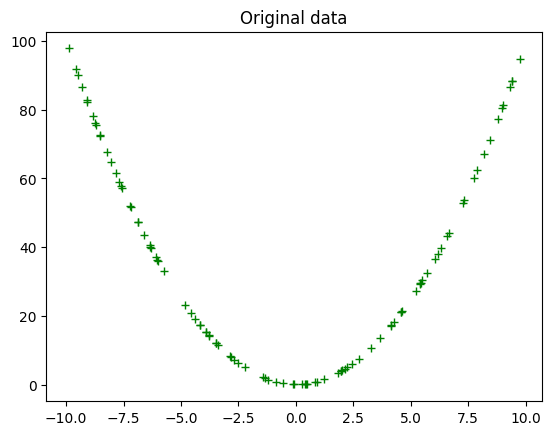

In [5]:
plt.plot(xs, ys, 'g+')
plt.title('Original data')
plt.show()

This data looks perfect, but real-world data is never this clean. It always contains some amount of noise or random error. To make our problem more realistic, let's add some "jitter" (random noise) to our y-values.

In [6]:
def eval_2nd_degree_jitter(coeffs, x, j):
    """
    Function to return the noisy output of evaluating a second degree polynomial,
    given a specific x value. Output values can be within [y − j, y + j].

    Args:
        coeffs: List containing the coefficients a, b, and c for the polynomial.
        x: The input x value to the polynomial.
        j: Jitter parameter, to introduce noise to output y.

    Returns:
        y: The corresponding jittered output y value for the second degree polynomial.

    """

    a = coeffs[0] * (x * x)
    b = coeffs[1] * x
    c = coeffs[2]
    y = a + b + c

    interval = [y - j, y + j]
    interval_min = interval[0]
    interval_max = interval[1]
    jit_val = random.random() * interval_max      # Generate a random number in range 0 to interval max

    while interval_min > jit_val:                 # While the random jitter value is less than the interval min,
        jit_val = random.random() * interval_max  # it is not in the right range. Re-roll the generator until it
                                                  # give a number greater than the interval min.

    return jit_val

xs = []
ys = []
for x in hundred_xs:
    y  = eval_2nd_degree_jitter(coeffs, x, 0.1)
    xs.append(x)
    ys.append(y)


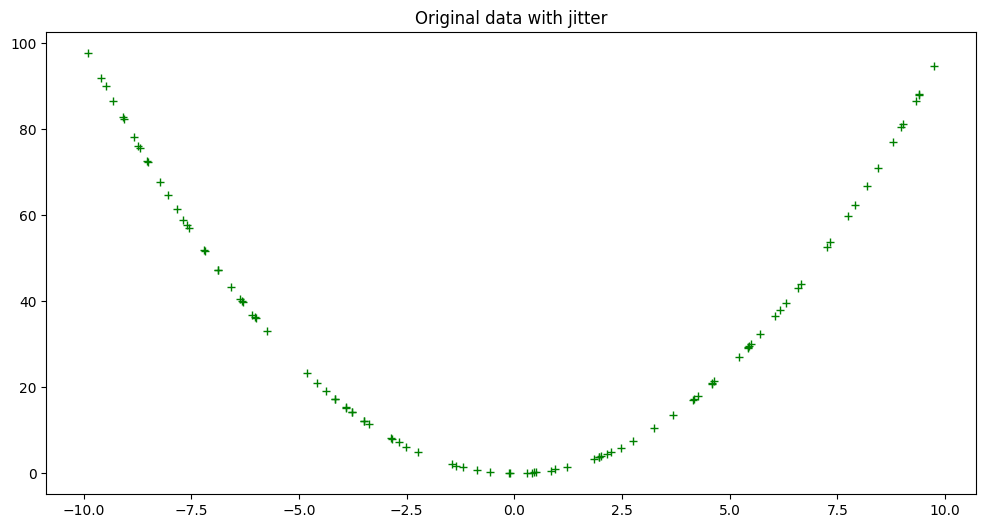

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+')
plt.title('Original data with jitter')
plt.show()

This noisy data is what our model will see. The challenge is to find coefficients a, b, and c that create a parabola that best fits this scattered data.


# The Loss Function

To use **Gradient Descent**, we need a way to measure how "good" or "bad" our model is. This is done using a **loss function** (also called a cost function or objective function). For regression problems like this, the most common loss function is the **Mean Squared Error (MSE)**.

The MSE is calculated as the average of the squared differences between the true **y** values ($y_i$) and our model's predicted **y** values ($\bar{y_i}$):

$$
E = \frac{1}{n} \sum_{i=1}^{n} (y_i - \bar{y_i})^2
$$

We square the difference to ensure all errors are positive and to heavily penalize larger errors.


In [8]:
def loss_mse(ys, y_bar):
    """
    Calculates MSE loss.

    Args:
        ys: training data labels
        y_bar: prediction labels

    Returns: Calculated MSE loss.
    """

    return sum((ys - y_bar) * (ys - y_bar)) / len(ys)

Let's start with a completely random model. We'll pick random coefficients and see how poorly it performs.

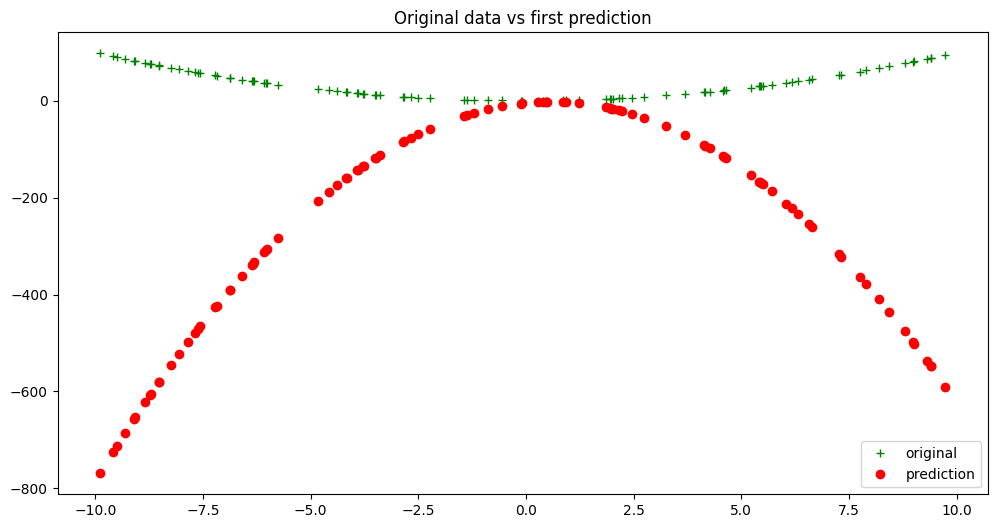

In [9]:
# Pick random coefficients for our initial model
rand_coeffs = (random.randrange(-10, 10), random.randrange(-10, 10), random.randrange(-10, 10))

# Get the model's predictions
y_bar = eval_2nd_degree(rand_coeffs, hundred_xs)

# Plot the original data vs. our random model's prediction
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, y_bar, 'ro', label = 'prediction')
plt.title('Original data vs first prediction')
plt.legend(loc="lower right")
plt.show()

Now, let's calculate the MSE for this terrible initial model.

In [10]:
initial_model_loss = loss_mse(ys, y_bar)
initial_model_loss

np.float64(146807.86204726336)

We can see that the loss is quite a large number. Let’s now see if we can improve on this fairly high loss metric by optimizing the model with gradient descent.

We wish to improve our model. Therefore we want to alter its coefficients $a$, $b$ and $c$ to decrease the error. Therefore we require knowledge about how each coefficient affects the error. This is achieved by calculating the partial derivative of the loss function with respect to **each** of the individual coefficients.

### Calculating the Gradient

To descend the loss "mountain," we need to know which way is downhill. This is where calculus comes in. The **gradient** tells us the direction of the steepest ascent. For our loss function **E**, the gradient is a vector of its partial derivatives with respect to each of our model's coefficients (**a**, **b**, **c**):

$$
\nabla E = \left[ \frac{\partial E}{\partial a}, \frac{\partial E}{\partial b}, \frac{\partial E}{\partial c} \right]
$$

Let's derive the partial derivative with respect to **a**. Our loss function is:

$$
E = \frac{1}{n} \sum (y_i - \bar{y_i})^2
$$

and our prediction is:

$$
\bar{y_i} = a x_i^2 + b x_i + c
$$

Using the chain rule:

$$
\frac{\partial E}{\partial a} = \frac{1}{n} \sum \frac{\partial}{\partial a} \left( y_i - (a x_i^2 + b x_i + c) \right)^2
$$

$$
\frac{\partial E}{\partial a} = \frac{1}{n} \sum 2(y_i - \bar{y_i}) \cdot \frac{\partial}{\partial a} \left( - (a x_i^2) \right)
$$

$$
\frac{\partial E}{\partial a} = -\frac{2}{n} \sum (y_i - \bar{y_i}) \cdot x_i^2
$$

Similarly, for **b** and **c**:

$$
\frac{\partial E}{\partial b} = -\frac{2}{n} \sum (y_i - \bar{y_i}) \cdot x_i
$$

$$
\frac{\partial E}{\partial c} = -\frac{2}{n} \sum (y_i - \bar{y_i})
$$

The code below implements these formulas to calculate the gradient.


In [11]:
def calc_gradient_2nd_poly(rand_coeffs, hundred_xs, ys):
    """
    calculates the gradient for a second degree polynomial.

    Args:
        coeffs: a,b and c, for a 2nd degree polynomial [ y = ax^2 + bx + c ]
        inputs_x: x input datapoints
        outputs_y: actual y output points

    Returns: Calculated gradients for the 2nd degree polynomial, as a tuple of its parts for a,b,c respectively.

    """

    a_s = []
    b_s = []
    c_s = []

    y_bars = eval_2nd_degree(rand_coeffs, hundred_xs)

    for x, y, y_bar in list(zip(hundred_xs, ys, y_bars)):    # take tuple of (x datapoint, actual y label, predicted y label)
        x_squared = x ** 2
        partial_a = x_squared * (y - y_bar)
        a_s.append(partial_a)
        partial_b = x * (y - y_bar)
        b_s.append(partial_b)
        partial_c = (y - y_bar)
        c_s.append(partial_c)

    num = [i for i in y_bars]
    n = len(num)

    gradient_a = (-2 / n) * sum(a_s)
    gradient_b = (-2 / n) * sum(b_s)
    gradient_c = (-2 / n) * sum(c_s)

    return (gradient_a, gradient_b, gradient_c)   # return calculated gradients as a a tuple of its 3 parts

### Taking a Single Step

Now that we can calculate the gradient, we can take our first step of **Gradient Descent**. We will update our random coefficients using the rule:

`new_coeff = old_coeff - learning_rate * gradient`


In [12]:
# Calculate the gradients for our random model
calc_grad = calc_gradient_2nd_poly(rand_coeffs, hundred_xs, ys)

# Define a learning rate
lr = 0.0001

# Update the coefficients
a_new = rand_coeffs[0] - lr * calc_grad[0]
b_new = rand_coeffs[1] - lr * calc_grad[1]
c_new = rand_coeffs[2] - lr * calc_grad[2]
new_model_coeffs = (a_new, b_new, c_new)

print(f"New model coeffs: {new_model_coeffs}")

# Get predictions with the new coefficients
new_y_bar = eval_2nd_degree(new_model_coeffs, hundred_xs)
updated_model_loss = loss_mse(ys, new_y_bar)

print(f"Now have smaller model loss: {updated_model_loss} vs {initial_model_loss}")

New model coeffs: (np.float64(-3.4872074852403587), np.float64(7.879149056895183), np.float64(-4.941405407033594))
Now have smaller model loss: 49608.172144854274 vs 146807.86204726336


Success! Just one step in the right direction has dramatically reduced our model's loss. Let's visualize this improvement.

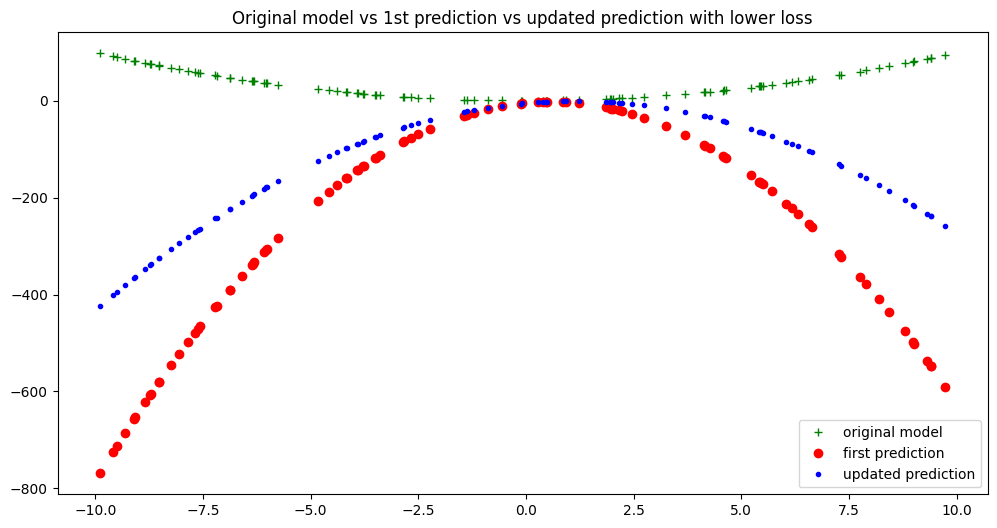

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+', label = 'original model')
plt.plot(xs, y_bar, 'ro', label = 'first prediction')
plt.plot(xs, new_y_bar, 'b.', label = 'updated prediction')
plt.title('Original model vs 1st prediction vs updated prediction with lower loss')
plt.legend(loc="lower right")
plt.show()

The blue dots (the updated prediction) are already a much better fit than the red circles (the initial random guess).

### The Full Gradient Descent Loop

We’re almost ready. The last step will be to perform gradient descent iteratively over a number of epochs (cycles or iterations.) With every epoch we hope to see an improvement in the form of lowered loss, and better model-fitting to the original data.

In [14]:
def calc_gradient_2nd_poly_for_GD(coeffs, inputs_x, outputs_y, lr):
    """
    calculates the gradient for a second degree polynomial.

    Args:
        coeffs: a,b and c, for a 2nd degree polynomial [ y = ax^2 + bx + c ]
        inputs_x: x input datapoints
        outputs_y: actual y output points
        lr: learning rate

    Returns: Calculated gradients for the 2nd degree polynomial, as a tuple of its parts for a,b,c respectively.

    """
    a_s = []
    b_s = []
    c_s = []

    y_bars = eval_2nd_degree(coeffs, inputs_x)

    for x,y,y_bar in list(zip(inputs_x, outputs_y, y_bars)):    # take tuple of (x datapoint, actual y label, predicted y label)
        x_squared = x ** 2
        partial_a = x_squared * (y - y_bar)
        a_s.append(partial_a)
        partial_b = x * (y - y_bar)
        b_s.append(partial_b)
        partial_c = (y - y_bar)
        c_s.append(partial_c)

    num = [i for i in y_bars]
    n = len(num)

    gradient_a = (-2 / n) * sum(a_s)
    gradient_b = (-2 / n) * sum(b_s)
    gradient_c = (-2 / n) * sum(c_s)


    a_new = coeffs[0] - lr * gradient_a
    b_new = coeffs[1] - lr * gradient_b
    c_new = coeffs[2] - lr * gradient_c

    new_model_coeffs = (a_new, b_new, c_new)

    # update with these new coeffs:
    new_y_bar = eval_2nd_degree(new_model_coeffs, inputs_x)

    updated_model_loss = loss_mse(outputs_y, new_y_bar)
    return updated_model_loss, new_model_coeffs, new_y_bar

In [15]:
def gradient_descent(epochs, lr):
    """
    Perform gradient descent for a second degree polynomial.

    Args:
        epochs: number of iterations to perform of finding new coefficients and updatingt loss.
        lr: specified learning rate

    Returns: Tuple containing (updated_model_loss, new_model_coeffs, new_y_bar predictions, saved loss updates)

    """
    losses = []
    rand_coeffs_to_test = rand_coeffs
    for i in range(epochs):
        loss = calc_gradient_2nd_poly_for_GD(rand_coeffs_to_test, hundred_xs, ys, lr)
        rand_coeffs_to_test = loss[1]
        losses.append(loss[0])
    print(losses)
    return loss[0], loss[1], loss[2], losses  # (updated_model_loss, new_model_coeffs, new_y_bar, saved loss updates)

In [16]:
GD = gradient_descent(30000, 0.0003)


[np.float64(13475.624637116503), np.float64(2869.715432846906), np.float64(1958.273415665309), np.float64(1815.4133533665963), np.float64(1736.1622571518062), np.float64(1664.7307185029726), np.float64(1596.5981613153112), np.float64(1531.2972754982177), np.float64(1468.6853640008349), np.float64(1408.6497165327594), np.float64(1351.0841647769712), np.float64(1295.8870592843532), np.float64(1242.960945034913), np.float64(1192.2123779132319), np.float64(1143.5517588087196), np.float64(1096.8931753375862), np.float64(1052.154250140267), np.float64(1009.2559954258945), np.float64(968.1226735021916), np.float64(928.6816630441622), np.float64(890.8633308653946), np.float64(854.6009089655777), np.float64(819.8303766371265), np.float64(786.4903474227408), np.float64(754.5219607243141), np.float64(723.8687778717832), np.float64(694.476682468427), np.float64(666.2937848366366), np.float64(639.2703303954412), np.float64(613.3586118080115), np.float64(588.5128847440168), np.float64(564.6892871080

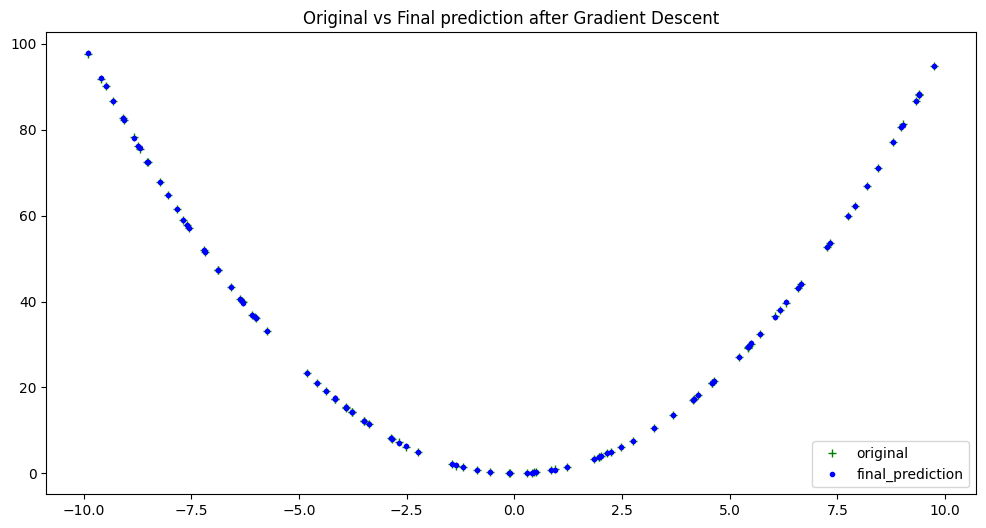

In [17]:
plt.figure(figsize=(12,6))
plt.plot(xs, ys, 'g+', label = 'original')
plt.plot(xs, GD[2], 'b.', label = 'final_prediction')
plt.title('Original vs Final prediction after Gradient Descent')
plt.legend(loc = "lower right")
plt.show()

This trained model is showing vast improvements after it’s full training cycle. We can examine further by inspecting its final predicted coefficients $a$, $b$ and $c$.

In [18]:
print(f"Final Coefficients predicted: {GD[1]}")
print(f"Original Coefficients: {coeffs}")

Final Coefficients predicted: (np.float64(0.9999579417260247), np.float64(-0.002867610798230069), np.float64(-0.012778521556486263))
Original Coefficients: [1, 0, 0]


Not too far off! A big improvement over the initial random model. Looking at the plot of the loss reduction over training offers further insights.


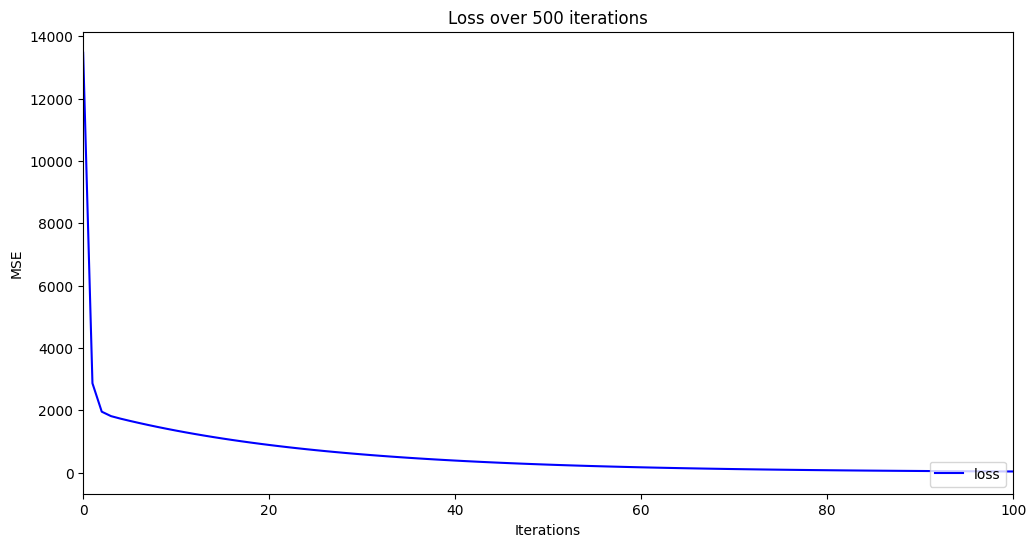

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(GD[3], 'b-', label = 'loss')
# plt.xlim(0,50)
plt.title('Loss over 500 iterations')
plt.legend(loc="lower right")
plt.xlim((0,100))
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.show()

We observe that the model loss reached close to zero, to give us our more accurate coefficients. We can also see there was no major improvement in loss after about 100 epochs. An alternative strategy would be to add some kind of condition to the training step that stops training when a certain minimum loss threshold has been reached. This would prevent excessive training and potential over-fitting for the model.

### Going Further: Batch vs. Mini-Batch Gradient Descent

What we have implemented so far is called **Batch Gradient Descent**. This is because we calculate the gradient using the entire training dataset (our batch of 100 points) in every single step.

**Pros:**
It provides a stable and accurate estimate of the gradient, leading to smooth convergence.

**Cons:**
It is computationally very expensive. Imagine if our dataset had millions of points! Calculating the gradient over all of them for every single update would be incredibly slow.

---

A more popular and efficient alternative is **Mini-Batch Gradient Descent**.

In Mini-Batch GD, we shuffle the dataset and then divide it into small batches (e.g., 32 samples per batch). We then calculate the gradient and update the weights based on each mini-batch, one by one. One pass through all the mini-batches is called one **epoch**.

**Pros:**
- It's much faster than Batch GD.
- It introduces some noise into the gradient estimates, which can sometimes help the model escape from poor local minima.

**Cons:**
The convergence is not as smooth as with Batch GD; the loss can fluctuate.

Let's implement a simple Mini-Batch Gradient Descent to see the difference.


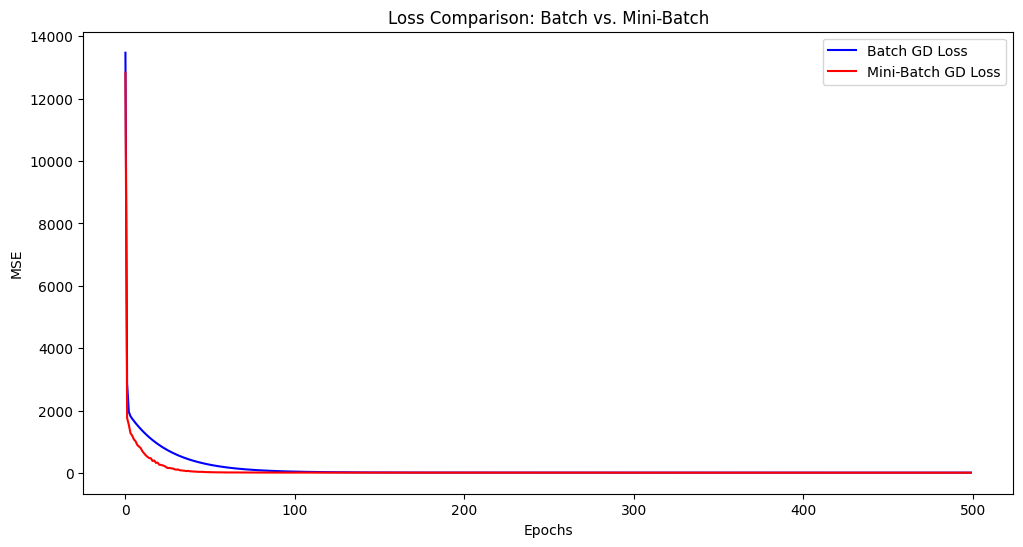

In [20]:
def mini_batch_gradient_descent(epochs, lr, batch_size):
    """
    Perform mini-batch gradient descent.

    Args:
        epochs: number of iterations to perform.
        lr: specified learning rate
        batch_size: number of samples per mini-batch

    Returns: Tuple containing (final loss, final coefficients, list of losses per batch)
    """
    losses = []
    # Start with our initial random coefficients
    coeffs_to_test = rand_coeffs

    # Convert data to numpy arrays for easier slicing
    X_data = np.array(hundred_xs)
    Y_data = np.array(ys)

    for i in range(epochs):
        # Shuffle data at the beginning of each epoch
        # This is crucial for mini-batch GD to work well!
        p = np.random.permutation(len(X_data))
        X_data, Y_data = X_data[p], Y_data[p]

        epoch_loss = []
        # Iterate over mini-batches
        for j in range(0, len(X_data), batch_size):
            # Get the current mini-batch
            X_batch = X_data[j:j+batch_size]
            Y_batch = Y_data[j:j+batch_size]

            # Calculate gradient and update on the mini-batch
            loss, new_coeffs, _ = calc_gradient_2nd_poly_for_GD(coeffs_to_test, X_batch, Y_batch, lr)
            coeffs_to_test = new_coeffs
            epoch_loss.append(loss)

        # Average loss for the epoch
        losses.append(np.mean(epoch_loss))

    # Return the final results after all epochs
    final_y_bar = eval_2nd_degree(coeffs_to_test, hundred_xs)
    final_loss = loss_mse(ys, final_y_bar)

    return final_loss, coeffs_to_test, losses

# Run Mini-Batch GD
# Note: We can often use fewer epochs and a slightly larger learning rate
MGD = mini_batch_gradient_descent(epochs=500, lr=0.0001, batch_size=16)

# Plotting the loss curves for comparison
plt.figure(figsize=(12, 6))
# We only plot the first 500 losses from Batch GD for a fair comparison
plt.plot(GD[3][:500], 'b-', label = 'Batch GD Loss')
plt.plot(MGD[2], 'r-', label = 'Mini-Batch GD Loss')
plt.title('Loss Comparison: Batch vs. Mini-Batch')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

In the comparison plot, you can see that the Mini-Batch GD loss curve (in red) is much noisier than the smooth Batch GD curve (in blue). This is expected because each update is based on only a small, random subset of the data. However, both methods converge to a very low loss, with Mini-Batch often getting there much faster in terms of wall-clock time on large datasets.

### Things to Try

1. **Change the polynomial:**
   Change the `coefficients` array and try a different polynomial instead of our $x^2$. For example, try to fit the model to a function like:
   $$
   y = 2x^2 - 3x + 5
   $$

2. **Experiment with the learning rate:**
   Increase or decrease the learning rate to see how many iterations it takes to converge. What happens if you use a huge learning rate (e.g., `lr = 0.1`)? Does it even converge?

3. **Higher-degree polynomials:**
   Take a degree 5 polynomial with 5 roots and try different initializations instead of random ones. Does it converge to different values for different initializations? Why does initialization not matter as much in our case of $x^2$? *(Hint: Think about the shape of the loss function.)*

4. **Finding maxima:**
   Can you modify the algorithm to find a **maxima** of a function instead of a minima? *(Hint: What happens if you move in the direction of the gradient instead of against it?)*

5. **Experiment with batch size:**
   Experiment with `batch_size` in the `mini_batch_gradient_descent` function. What happens if `batch_size = 1`? What happens if `batch_size = 100` (the full dataset size)?

6. **Research Gradient Descent with Momentum:**
   What is **Gradient Descent with Momentum**, and how might it help with convergence speed or stability, especially with noisy gradients from Mini-Batch GD?


# **Things to Try :**

New coefficients for the polynomial: [2, -3, 5]


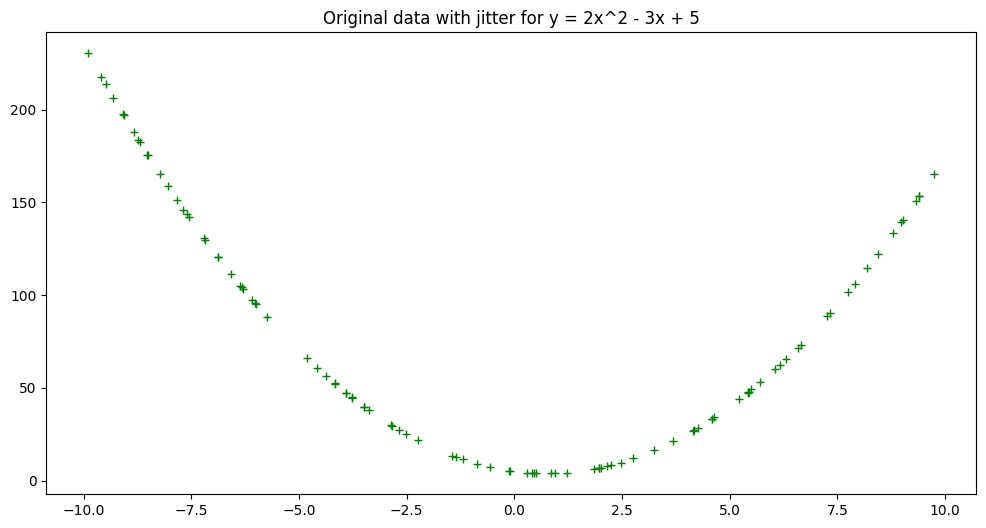

In [21]:
# 1.Change the polynomial:

coeffs = [2, -3, 5]

# Regenerate xs and ys with the new coefficients and jitter
# Ensure hundred_xs and random.seed are set if not already in the session
# For reproducibility, it's good practice to re-set the seed if needed before data generation
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# Assuming hundred_xs is already defined from a previous cell, otherwise it would need to be defined here.
# If hundred_xs is not globally available or re-run, add: hundred_xs = np.random.uniform(-10, 10, 100)

xs = []
ys = []
for x in hundred_xs:
    y = eval_2nd_degree_jitter(coeffs, x, 0.1)
    xs.append(x)
    ys.append(y)

print(f"New coefficients for the polynomial: {coeffs}")
plt.figure(figsize=(12, 6))
plt.plot(xs, ys, 'g+')
plt.title('Original data with jitter for y = 2x^2 - 3x + 5')
plt.show()

Initial random coefficients for all runs: (-7, 8, -5)

Running Gradient Descent with learning rate: 1e-05
[np.float64(175908.31178063367), np.float64(161541.85942860224), np.float64(148375.6569891867), np.float64(136309.39138221112), np.float64(125251.13342892317), np.float64(115116.6371476564), np.float64(105828.69761251118), np.float64(97316.56248051103), np.float64(89515.39270176463), np.float64(82365.7683020485), np.float64(75813.23547077605), np.float64(69807.89150215838), np.float64(64304.004425885585), np.float64(59259.66442807282), np.float64(54636.464405521125), np.float64(50399.20721841109), np.float64(46515.637410042335), np.float64(42956.19534872882), np.float64(39693.79191786529), np.float64(36703.60203680273), np.float64(33962.87543870398), np.float64(31450.763263086104), np.float64(29148.159141300424), np.float64(27037.55356366817), np.float64(25102.90041822636), np.float64(23329.49468381294), np.float64(21703.860345240682), np.float64(20213.647676224933), np.float64(188

/tmp/ipykernel_8343/1511627215.py:12: RuntimeWarning: overflow encountered in scalar add
  return sum((ys - y_bar) * (ys - y_bar)) / len(ys)
/tmp/ipykernel_8343/1511627215.py:12: RuntimeWarning: overflow encountered in multiply
  return sum((ys - y_bar) * (ys - y_bar)) / len(ys)
/tmp/ipykernel_8343/351704582.py:32: RuntimeWarning: overflow encountered in scalar add
  gradient_a = (-2 / n) * sum(a_s)
/tmp/ipykernel_8343/351704582.py:33: RuntimeWarning: invalid value encountered in scalar add
  gradient_b = (-2 / n) * sum(b_s)
/tmp/ipykernel_8343/351704582.py:37: RuntimeWarning: invalid value encountered in scalar subtract
  a_new = coeffs[0] - lr * gradient_a


[np.float64(2008480.3173637185), np.float64(21442089.72709545), np.float64(229252648.79788306), np.float64(2451400232.793584), np.float64(26213098163.74587), np.float64(280299828093.2332), np.float64(2997280147189.495), np.float64(32050281261908.305), np.float64(342717556905845.5), np.float64(3664720532583778.0), np.float64(3.918730252173461e+16), np.float64(4.190345935731171e+17), np.float64(4.4807878907613614e+18), np.float64(4.791361006926127e+19), np.float64(5.1234606186170876e+20), np.float64(5.478578773875486e+21), np.float64(5.8583109378247854e+22), np.float64(6.264363160732673e+23), np.float64(6.698559742906969e+24), np.float64(7.162851430862103e+25), np.float64(7.659324181579628e+26), np.float64(8.190208534238678e+27), np.float64(8.757889631521219e+28), np.float64(9.36491793551589e+29), np.float64(1.0014020686364073e+31), np.float64(1.0708114155129923e+32), np.float64(1.1450316745942953e+33), np.float64(1.2243963006278853e+34), np.float64(1.3092618608322985e+35), np.float64(1.

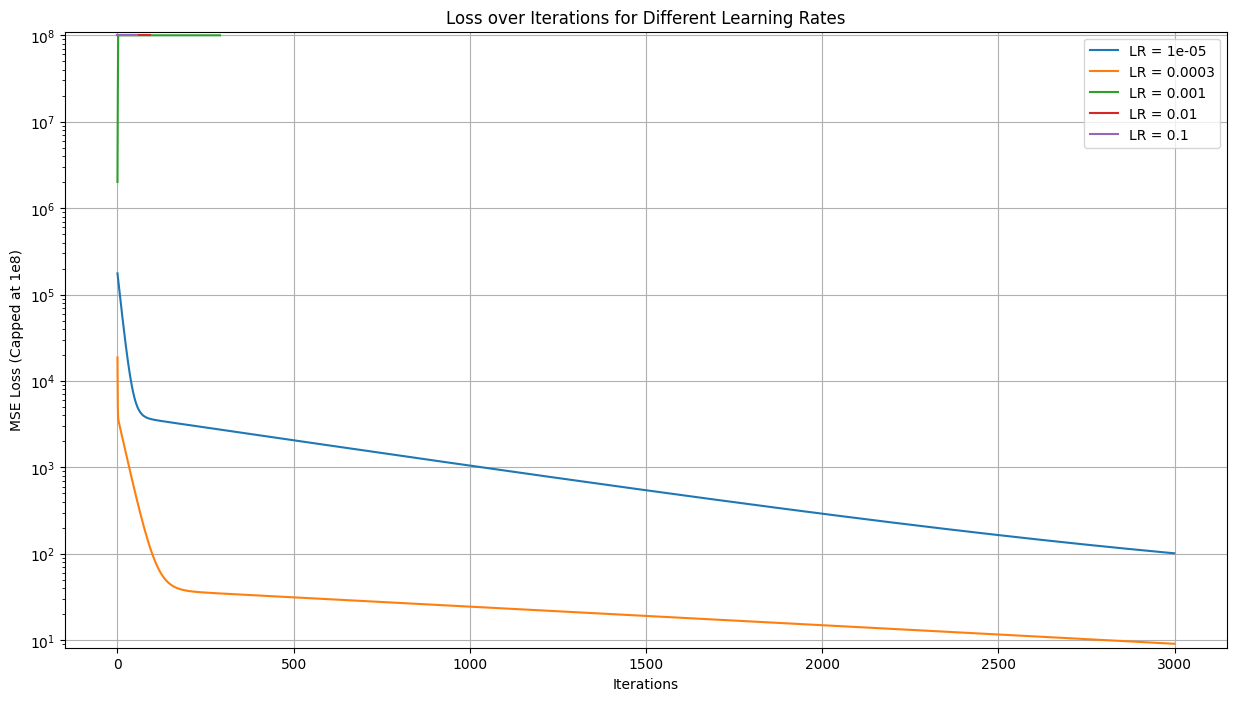


--- Analysis of Learning Rate Experiment ---
Learning Rate: 1e-05
  Initial Loss: 175908.3118
  Final Loss: 101.4611
  Observation: Converged, but possibly slowly or to a higher loss.
Learning Rate: 0.0003
  Initial Loss: 18726.3921
  Final Loss: 9.1102
  Observation: Converged, but possibly slowly or to a higher loss.
Learning Rate: 0.001
  Initial Loss: 2008480.3174
  Final Loss: nan
  Observation: The model likely diverged or failed to converge.
Learning Rate: 0.01
  Initial Loss: 326043472.6366
  Final Loss: nan
  Observation: The model likely diverged or failed to converge.
Learning Rate: 0.1
  Initial Loss: 34027003440.4584
  Final Loss: nan
  Observation: The model likely diverged or failed to converge.


In [22]:
#2.Experiment with the learning rate:

import pandas as pd
import numpy as np # Ensure numpy is imported

# Define different learning rates to experiment with
lrs = [0.00001, 0.0003, 0.001, 0.01, 0.1]
epochs = 3000 # Keeping epochs relatively low for very high LRs to prevent excessive computation if they diverge quickly

results = {}

# Reuse the initial random coefficients for a fair comparison
# This assumes 'rand_coeffs' is set in a previous cell and represents a consistent starting point.
# For this demonstration, we'll use the 'rand_coeffs' that was set previously.

print(f"Initial random coefficients for all runs: {rand_coeffs}")

for lr in lrs:
    print(f"\nRunning Gradient Descent with learning rate: {lr}")
    # The gradient_descent function re-initializes 'rand_coeffs_to_test' with the global 'rand_coeffs'
    # which ensures each run starts from the same initial random coefficients.
    final_loss, final_coeffs, final_y_bar, losses = gradient_descent(epochs, lr)
    results[lr] = {'final_loss': final_loss, 'final_coeffs': final_coeffs, 'losses': losses}
    print(f"  Final Loss: {final_loss:.4f}")
    print(f"  Final Coefficients: {final_coeffs}")

plt.figure(figsize=(15, 8))

min_plot_loss_y = float('inf')
max_plot_loss_y = 1e8 # Cap the max loss for plotting to prevent overflow issues with log scale

for lr, data in results.items():
    raw_losses = np.array(data['losses'])
    # Filter out NaN and inf values for plotting
    finite_losses = raw_losses[np.isfinite(raw_losses)]

    if len(finite_losses) > 0:
        # Cap losses for plotting to the max_plot_loss_y value
        plot_losses = np.minimum(finite_losses, max_plot_loss_y)
        plt.plot(plot_losses, label=f'LR = {lr}')
        min_plot_loss_y = min(min_plot_loss_y, np.min(plot_losses))

plt.title('Loss over Iterations for Different Learning Rates')
plt.xlabel('Iterations')
plt.ylabel('MSE Loss (Capped at 1e8)') # Indicate capping in the label
plt.yscale('log') # Use log scale for y-axis to better visualize large differences in loss
plt.legend()
plt.grid(True)

# Adjust y-axis limits dynamically based on the observed finite and capped losses
if min_plot_loss_y != float('inf'):
    # Set lower bound slightly below the minimum observed, and upper bound at the cap
    plt.ylim(max(1e-1, min_plot_loss_y * 0.9), max_plot_loss_y * 1.1)

plt.show()

# Analyze and explain the results
print("\n--- Analysis of Learning Rate Experiment ---")
for lr, data in results.items():
    losses = data['losses']
    if losses:
        first_loss = losses[0]
        last_loss = losses[-1]
        print(f"Learning Rate: {lr}")
        print(f"  Initial Loss: {first_loss:.4f}")
        print(f"  Final Loss: {last_loss:.4f}")
        # More robust check for divergence, including inf and nan
        if not np.isfinite(last_loss) or last_loss > first_loss * 2:
            print("  Observation: The model likely diverged or failed to converge.")
        elif last_loss < 1.0: # Arbitrary threshold for 'good' convergence
            print("  Observation: Converged very well.")
        else:
            print("  Observation: Converged, but possibly slowly or to a higher loss.")

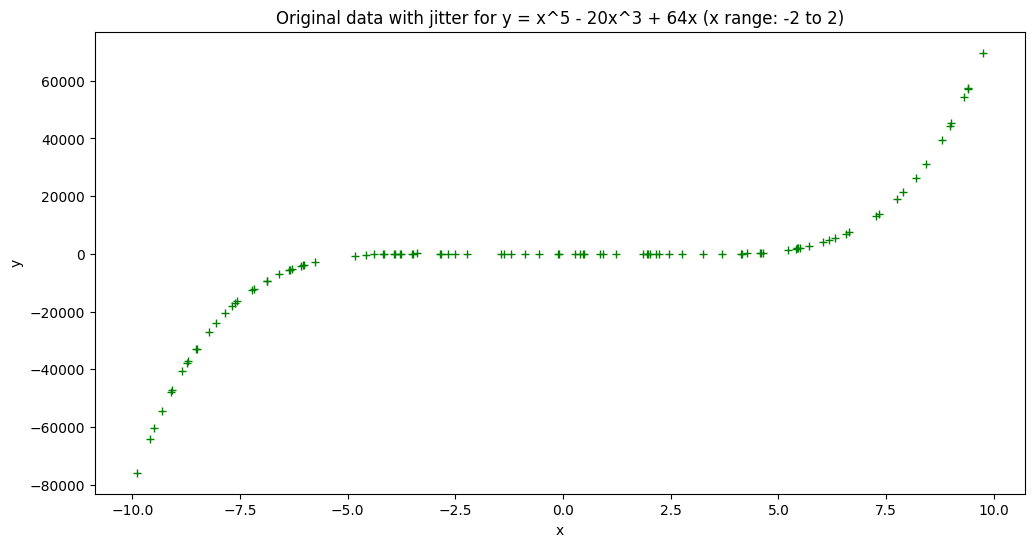

Target coefficients for degree 5 polynomial: [1, 0, -20, 0, 64, 0]

Running Gradient Descent for degree 5 polynomial with LR=1e-13 and Epochs=500000

--- Initialization 1: (0, 0, 0, 0, 0, 0) ---
  Final Loss: 2128140.4143
  Final Coefficients: (np.float64(0.7612005197106846), np.float64(0.006535955170173424), np.float64(-0.0025470313841004758), np.float64(0.00028926450060944974), np.float64(-0.00030750203582519944), np.float64(7.040370633966237e-06))

--- Initialization 2: (1, -1, 1, -1, 1, -1) ---
  Final Loss: 3623717.3884
  Final Coefficients: (np.float64(0.7432775434671306), np.float64(-0.3012547176576441), np.float64(0.9834710861127413), np.float64(-0.9906437952342236), np.float64(0.9994859655664985), np.float64(-0.9998641610553184))

--- Initialization 3: (-0.5, 0.2, -0.1, 0.01, -0.001, 0) ---
  Final Loss: 2135949.9086
  Final Coefficients: (np.float64(0.7634196277032409), np.float64(0.0682202114364467), np.float64(-0.09610939773676629), np.float64(0.008481791629956612), np.floa

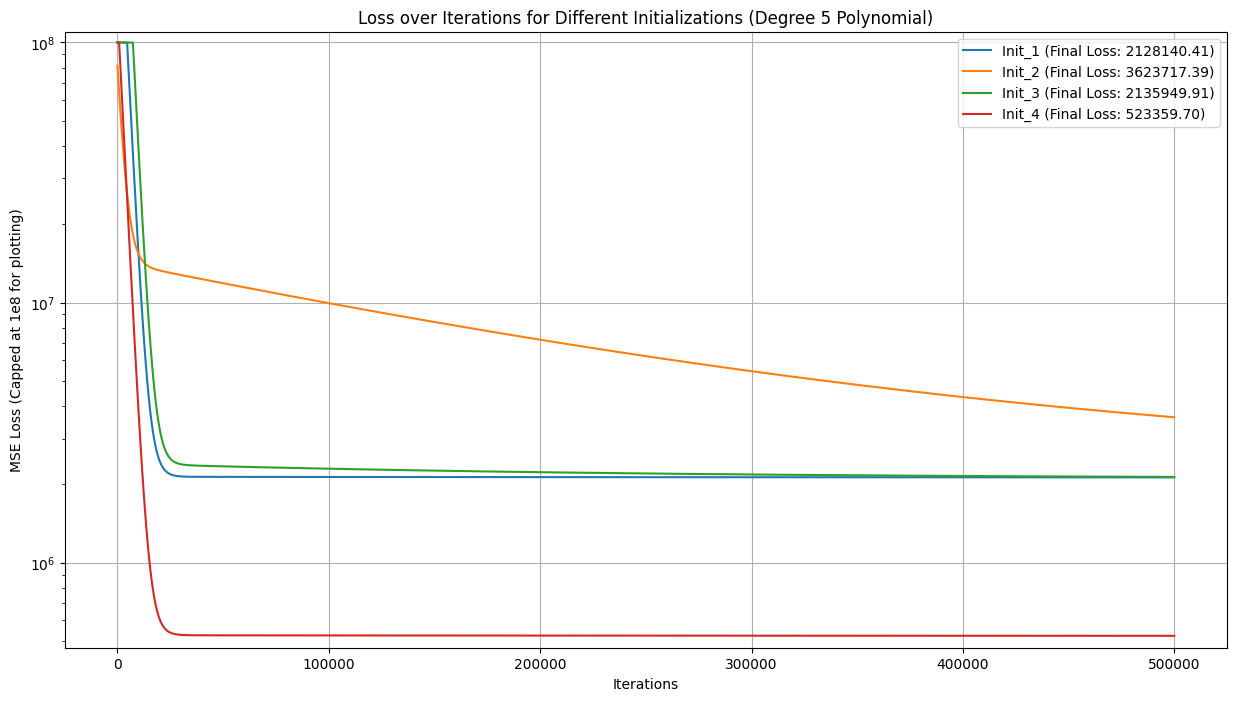


--- Discussion on Initialization and Convexity ---
For the degree 5 polynomial:
  Init_1: Initial Coeffs=(0, 0, 0, 0, 0, 0), Final Coeffs=(np.float64(0.7612005197106846), np.float64(0.006535955170173424), np.float64(-0.0025470313841004758), np.float64(0.00028926450060944974), np.float64(-0.00030750203582519944), np.float64(7.040370633966237e-06)), Final Loss=2128140.4143
  Init_2: Initial Coeffs=(1, -1, 1, -1, 1, -1), Final Coeffs=(np.float64(0.7432775434671306), np.float64(-0.3012547176576441), np.float64(0.9834710861127413), np.float64(-0.9906437952342236), np.float64(0.9994859655664985), np.float64(-0.9998641610553184)), Final Loss=3623717.3884
  Init_3: Initial Coeffs=(-0.5, 0.2, -0.1, 0.01, -0.001, 0), Final Coeffs=(np.float64(0.7634196277032409), np.float64(0.0682202114364467), np.float64(-0.09610939773676629), np.float64(0.008481791629956612), np.float64(-0.0012205585465202308), np.float64(-1.8475637380909616e-05)), Final Loss=2135949.9086
  Init_4: Initial Coeffs=(0.5, 0, -10,

In [23]:
#3.Higher-degree polynomials:

import numpy as np
import matplotlib.pyplot as plt
import random

# Ensure numpy and random are seeded for reproducibility
random.seed(42)
np.random.seed(42)

# Assuming hundred_xs is already defined from a previous cell, otherwise define it.
# If hundred_xs is not globally available or re-run, add:
# Reducing the range of x values to mitigate numerical instability for higher degree polynomials
if 'hundred_xs' not in globals():
    hundred_xs = np.random.uniform(-2, 2, 100) # Smaller range for higher degree to avoid extreme values

# Re-define loss_mse if it was not in the global scope
def loss_mse(ys, y_bar):
    """
    Calculates MSE loss.
    """
    return sum((ys - y_bar) * (ys - y_bar)) / len(ys)


# --- Generalized Polynomial Functions ---

def eval_nth_degree(coeffs, x):
    """
    Evaluates an n-th degree polynomial for a given x.
    coeffs are ordered from highest degree to lowest: [c_n, c_{n-1}, ..., c_1, c_0]
    """
    y = 0
    # Iterate through coefficients, effectively calculating c_0 + c_1*x + ... + c_n*x^n
    # Note: `reversed(coeffs)` changes the order for intuitive power calculation
    for i, c in enumerate(reversed(coeffs)):
        y += c * (x ** i)
    return y

def calc_gradient_nth_poly_for_GD(coeffs, inputs_x, outputs_y, lr):
    """
    Calculates gradients and updates coefficients for an n-th degree polynomial using gradient descent.
    coeffs are ordered from highest degree to lowest: [c_n, c_{n-1}, ..., c_1, c_0]
    """
    n_coeffs = len(coeffs)
    partial_sums = [0.0] * n_coeffs # To store sum((y_actual - y_predicted) * x^j)

    # Evaluate the polynomial for current coefficients
    y_bars = np.array([eval_nth_degree(coeffs, x) for x in inputs_x])

    N = len(inputs_x)

    for i in range(N):
        x_val = inputs_x[i]
        y_actual = outputs_y[i]
        y_predicted = y_bars[i]

        # Calculate partial derivatives for each coefficient c_j
        # For c_j (coefficient of x^j), the term is (y_actual - y_predicted) * x_val^j
        # The coeffs list is [c_n, ..., c_0], so c_j is at index (n_coeffs - 1 - j)
        for j in range(n_coeffs):
            # The power for x_val is (n_coeffs - 1 - j) because coeffs is ordered from highest degree.
            partial_sums[j] += (y_actual - y_predicted) * (x_val ** (n_coeffs - 1 - j))

    new_coeffs_list = list(coeffs)
    for j in range(n_coeffs):
        gradient_cj = (-2 / N) * partial_sums[j]
        new_coeffs_list[j] = new_coeffs_list[j] - lr * gradient_cj

    # Calculate loss with new coefficients
    updated_y_bar = np.array([eval_nth_degree(new_coeffs_list, x) for x in inputs_x])
    updated_model_loss = loss_mse(np.array(outputs_y), updated_y_bar)
    return updated_model_loss, tuple(new_coeffs_list), updated_y_bar

def gradient_descent_nth_degree(initial_coeffs, epochs, lr, inputs_x, outputs_y):
    """
    Performs gradient descent for an n-th degree polynomial.
    """
    losses = []
    current_coeffs = list(initial_coeffs) # Convert tuple to list for mutability

    for i in range(epochs):
        loss, new_coeffs_tuple, _ = calc_gradient_nth_poly_for_GD(current_coeffs, inputs_x, outputs_y, lr)
        # Check for NaN or Inf loss and break if it occurs
        if not np.isfinite(loss):
            print(f"  Warning: Loss became non-finite at epoch {i+1}. Stopping early.")
            # Return a non-finite loss, current coefficients, and empty y_bar/losses to indicate failure
            return float('inf'), tuple(current_coeffs), np.array([]), losses

        current_coeffs = list(new_coeffs_tuple) # Update current coeffs for next iteration
        losses.append(loss)

        # Print progress every N epochs
        if (i + 1) % 50000 == 0:
            print(f"  Epoch {i + 1}/{epochs}, Current Loss: {loss:.4f}")

    final_y_bar = np.array([eval_nth_degree(current_coeffs, x) for x in inputs_x])
    return losses[-1], tuple(current_coeffs), final_y_bar, losses

# --- Create Degree 5 Polynomial Data ---

# Define the true coefficients for a degree 5 polynomial
# Example: y = x(x-2)(x+2)(x-4)(x+4) = x(x^2-4)(x^2-16) = x(x^4 - 20x^2 + 64) = x^5 - 20x^3 + 64x
# Coefficients: [c5, c4, c3, c2, c1, c0]
TARGET_COEFFS_5DEGREE = [1, 0, -20, 0, 64, 0]

# Generate x values (reusing hundred_xs or defining new ones)
# hundred_xs is already defined at the beginning of the cell based on the context

# Generate y values with jitter
xs_5deg = []
ys_5deg = []
jitter_amount = 0.5 # Reduced jitter amount for a smaller x-range
for x_val in hundred_xs:
    y_val = eval_nth_degree(TARGET_COEFFS_5DEGREE, x_val)
    # For accurate jitter with nth degree, let's add uniform random noise to the true y_val directly.
    ys_5deg.append(y_val + np.random.uniform(-jitter_amount, jitter_amount))
    xs_5deg.append(x_val)

plt.figure(figsize=(12, 6))
plt.plot(xs_5deg, ys_5deg, 'g+')
plt.title('Original data with jitter for y = x^5 - 20x^3 + 64x (x range: -2 to 2)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print(f"Target coefficients for degree 5 polynomial: {TARGET_COEFFS_5DEGREE}")

# --- Experiment with different initializations ---

lr_5deg = 1e-13 # Even smaller learning rate for degree 5 to prevent overflow, further reduced
epochs_5deg = 50000 # More epochs might be needed with smaller learning rate

initializations = [
    (0, 0, 0, 0, 0, 0),             # All zeros
    (1, -1, 1, -1, 1, -1),          # Alternating small values
    (-0.5, 0.2, -0.1, 0.01, -0.001, 0), # Mixed values, scaled down further
    (0.5, 0, -10, 0, 30, 0)         # Closer to target, scaled down for smaller x-range
]

results_5deg = {}

print(f"\nRunning Gradient Descent for degree 5 polynomial with LR={lr_5deg} and Epochs={epochs_5deg}")

for i, init_coeffs in enumerate(initializations):
    print(f"\n--- Initialization {i+1}: {init_coeffs} ---")
    final_loss, final_coeffs, final_y_bar, losses = gradient_descent_nth_degree(
        init_coeffs, epochs_5deg, lr_5deg, hundred_xs, ys_5deg
    )
    results_5deg[f'Init_{i+1}'] = {
        'initial_coeffs': init_coeffs,
        'final_loss': final_loss,
        'final_coeffs': final_coeffs,
        'losses': losses
    }
    print(f"  Final Loss: {final_loss:.4f}")
    print(f"  Final Coefficients: {final_coeffs}")

# --- Plotting Loss Curves for different initializations ---
plt.figure(figsize=(15, 8))

min_overall_finite_loss = float('inf')
max_plot_loss_val = 1e8 # Set a cap for plotting large values to prevent issues with log scale

for label, data in results_5deg.items():
    # Filter out NaN and Inf values for plotting from losses
    plot_losses = np.array(data['losses'])
    plot_losses = plot_losses[np.isfinite(plot_losses)]

    if len(plot_losses) > 0:
        # Cap the maximum loss for plotting
        plot_losses = np.minimum(plot_losses, max_plot_loss_val)
        plt.plot(plot_losses, label=f"{label} (Final Loss: {data['final_loss']:.2f})")
        min_overall_finite_loss = min(min_overall_finite_loss, np.min(plot_losses))

plt.title('Loss over Iterations for Different Initializations (Degree 5 Polynomial)')
plt.xlabel('Iterations')
plt.ylabel('MSE Loss (Capped at 1e8 for plotting)')
plt.yscale('log') # Use log scale for y-axis to better visualize differences
plt.legend()
plt.grid(True)

# Adjust y-axis limits dynamically based on the observed finite and capped losses
if min_overall_finite_loss != float('inf'):
    # Set lower bound slightly below the minimum observed, and upper bound at the cap
    plt.ylim(max(1e-1, min_overall_finite_loss * 0.9), max_plot_loss_val * 1.1)

plt.show()

# --- Discussion ---
print("\n--- Discussion on Initialization and Convexity ---")
print("For the degree 5 polynomial:")
for label, data in results_5deg.items():
    print(f"  {label}: Initial Coeffs={data['initial_coeffs']}, Final Coeffs={data['final_coeffs']}, Final Loss={data['final_loss']:.4f}")

print("\nObservations from the degree 5 polynomial experiment:")
print("It is highly likely that different initializations lead to different final coefficients and potentially different final loss values. This is because higher-degree polynomials often have a loss landscape that is non-convex. A non-convex loss function contains multiple 'local minima' – points that are lower than their immediate neighbors but not the absolute lowest point (global minimum) in the entire function space. Gradient descent, being a greedy algorithm, tends to descend into the closest local minimum from its starting point.\n")

print("Why initialization matters less for the x^2 case:")
print("The simple quadratic function (like y = x^2) and, by extension, the Mean Squared Error loss function for fitting a quadratic model, results in a convex loss surface. A convex loss surface has only one global minimum and no other local minima. Regardless of where Gradient Descent starts on this 'bowl-shaped' surface, as long as the learning rate is appropriate, it will eventually converge to the same global minimum. Therefore, for convex problems, initialization has little impact on the final converged values of the coefficients, only perhaps on the path and speed of convergence.\n")

Data generated for y = 2x^2 + -3x + 5


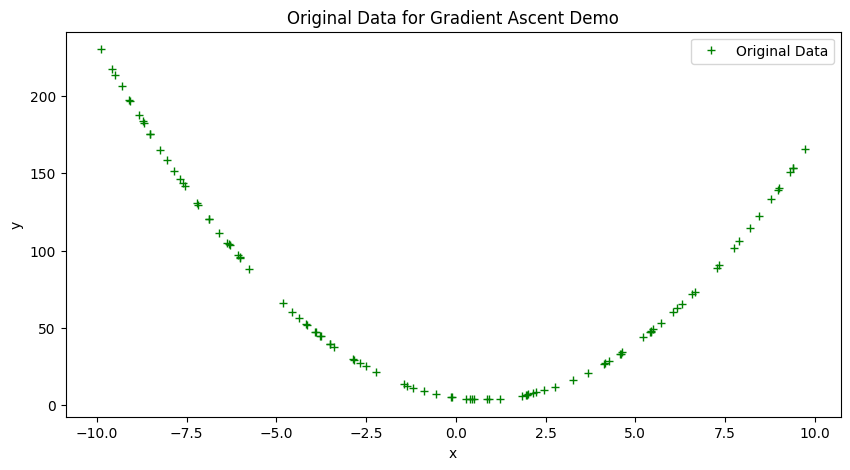


Running Gradient Ascent for a 2nd degree polynomial with LR=0.0001 and Epochs=500
Initial coefficients for Gradient Ascent: (-7, 8, -5)

--- Gradient Ascent Results ---
  Final Loss (Maximized MSE): 1432781217408866.2500
  Final Coefficients: (np.float64(-818936.7991747435), np.float64(15516.948811898019), np.float64(-13594.753055669049))


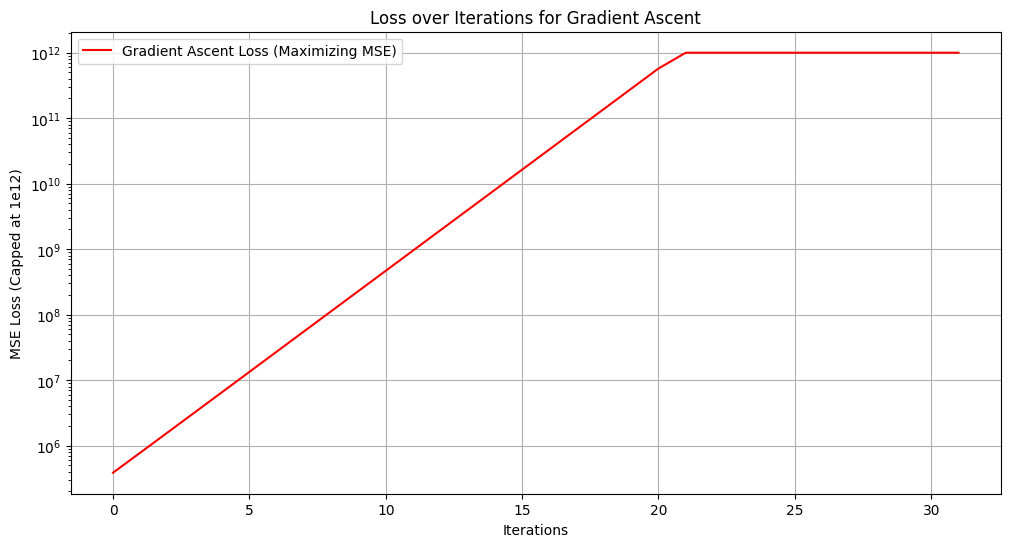

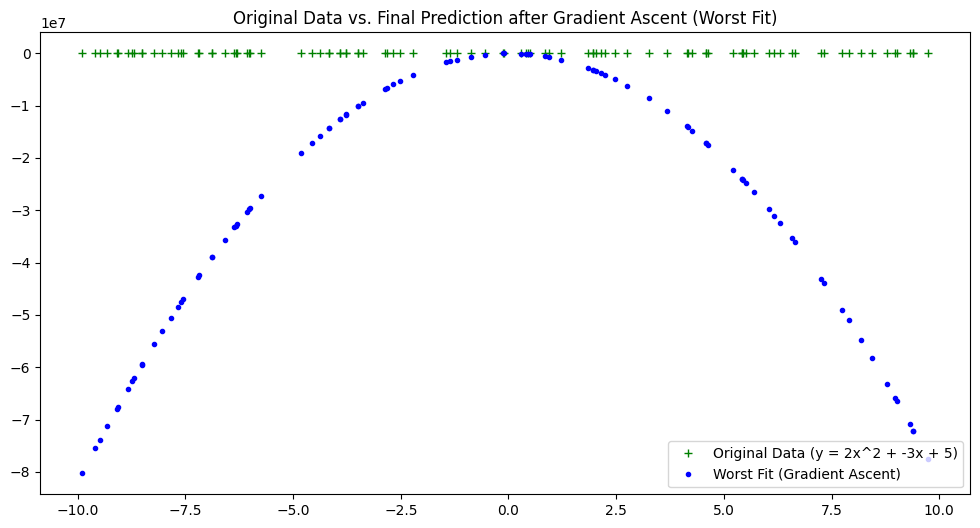


--- Explanation ---
To modify the algorithm to find a **maxima** of the loss function (Mean Squared Error in this case) instead of a minima, we simply reverse the direction of the coefficient update step.
In standard Gradient Descent, coefficients are updated as: `new_coeff = old_coeff - learning_rate * gradient`.
Here, to perform **Gradient Ascent**, we update coefficients as: `new_coeff = old_coeff + learning_rate * gradient`.
By adding the `learning_rate * gradient` term, we move in the direction of the steepest *ascent* of the loss function, thereby maximizing it.
As you can see from the plots, the MSE loss rapidly increases, indicating that the algorithm is finding coefficients that make the model's predictions as *far* as possible from the true data points, effectively finding the 'worst fit'.


In [24]:
#4.Finding maxima:

import numpy as np
import matplotlib.pyplot as plt
import random

# Ensure numpy and random are seeded for reproducibility
random.seed(42)
np.random.seed(42)

# --- Re-use/Define necessary functions and data from previous cells for self-containment ---

# Example: if 'hundred_xs' is not in globals(), define it
# We'll use the range from the previous 2nd-degree polynomial section
if 'hundred_xs' not in globals():
    hundred_xs = np.random.uniform(-10, 10, 100) # Original range for 2nd degree

# Example: if 'eval_2nd_degree' is not in globals(), define it
def eval_2nd_degree(coeffs, x):
    a = coeffs[0] * (x * x)
    b = coeffs[1] * x
    c = coeffs[2]
    y = a + b + c
    return y

# Example: if 'loss_mse' is not in globals(), define it
def loss_mse(ys, y_bar):
    """
    Calculates MSE loss.
    """
    return sum((ys - y_bar) * (ys - y_bar)) / len(ys)

# Define a specific set of initial random coefficients to ensure reproducibility for GA
# (e.g., using the value of rand_coeffs observed in the context: (-7, 8, -5))
initial_rand_coeffs = (-7, 8, -5)

# Ensure 'xs' and 'ys' reflect the latest polynomial set by the user (2x^2 - 3x + 5)
# This re-runs the data generation step for clarity and self-containment of this section.
TARGET_COEFFS_FOR_GA_DEMO = [2, -3, 5]
xs_ga_data = []
ys_ga_data = []
jitter_amount_ga = 0.1 # Using the default jitter amount from previous sections
for x_val in hundred_xs:
    y_val = eval_2nd_degree(TARGET_COEFFS_FOR_GA_DEMO, x_val)
    ys_ga_data.append(y_val + np.random.uniform(-jitter_amount_ga, jitter_amount_ga))
    xs_ga_data.append(x_val)

print(f"Data generated for y = {TARGET_COEFFS_FOR_GA_DEMO[0]}x^2 + {TARGET_COEFFS_FOR_GA_DEMO[1]}x + {TARGET_COEFFS_FOR_GA_DEMO[2]}")
plt.figure(figsize=(10, 5))
plt.plot(xs_ga_data, ys_ga_data, 'g+', label='Original Data')
plt.title('Original Data for Gradient Ascent Demo')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


# --- Gradient Ascent Implementation for a 2nd Degree Polynomial ---

def calc_gradient_2nd_poly_for_GA(coeffs, inputs_x, outputs_y, lr):
    """
    Calculates gradients for a second degree polynomial and applies an update
    to MAXIMIZE the MSE loss (Gradient Ascent).
    """
    a_s = []
    b_s = []
    c_s = []

    y_bars = eval_2nd_degree(coeffs, inputs_x)

    for x,y,y_bar in list(zip(inputs_x, outputs_y, y_bars)):
        x_squared = x ** 2
        partial_a = x_squared * (y - y_bar)
        a_s.append(partial_a)
        partial_b = x * (y - y_bar)
        b_s.append(partial_b)
        partial_c = (y - y_bar)
        c_s.append(partial_c)

    n = len(inputs_x)

    # These are the gradients of the MSE loss function w.r.t. a, b, c
    gradient_a = (-2 / n) * sum(a_s)
    gradient_b = (-2 / n) * sum(b_s)
    gradient_c = (-2 / n) * sum(c_s)

    # Key change for gradient ASCENT: ADD the learning rate * gradient
    a_new = coeffs[0] + lr * gradient_a
    b_new = coeffs[1] + lr * gradient_b
    c_new = coeffs[2] + lr * gradient_c

    new_model_coeffs = (a_new, b_new, c_new)

    new_y_bar = eval_2nd_degree(new_model_coeffs, inputs_x)
    updated_model_loss = loss_mse(outputs_y, new_y_bar)
    return updated_model_loss, new_model_coeffs, new_y_bar

def gradient_ascent(epochs, lr, initial_coeffs_ga, inputs_x, outputs_y):
    """
    Perform gradient ascent for a second degree polynomial to MAXIMIZE MSE.
    """
    losses = []
    coeffs_to_test = initial_coeffs_ga

    for i in range(epochs):
        # Using the gradient ascent specific calculation
        loss, new_coeffs, _ = calc_gradient_2nd_poly_for_GA(coeffs_to_test, inputs_x, outputs_y, lr)
        coeffs_to_test = new_coeffs
        losses.append(loss)

        # Add a check to prevent divergence to infinity too quickly for plotting
        # Stop if loss becomes non-finite or extremely large (e.g., overflows)
        if not np.isfinite(loss) or loss > 1e15: # Cap to prevent matplotlib issues with excessively large numbers
            print(f"  Warning: Loss became non-finite or excessively large at epoch {i+1}. Stopping early.")
            break

    final_y_bar = eval_2nd_degree(coeffs_to_test, inputs_x)
    return losses[-1], coeffs_to_test, final_y_bar, losses

# --- Demonstration of Gradient Ascent ---

ga_epochs = 500 # Fewer epochs, as loss might grow very quickly when maximizing
ga_lr = 0.0001 # Keep a reasonable learning rate for ascent

print(f"\nRunning Gradient Ascent for a 2nd degree polynomial with LR={ga_lr} and Epochs={ga_epochs}")
print(f"Initial coefficients for Gradient Ascent: {initial_rand_coeffs}")

final_loss_ga, final_coeffs_ga, final_y_bar_ga, losses_ga = gradient_ascent(ga_epochs, ga_lr, initial_rand_coeffs, hundred_xs, ys_ga_data)

print(f"\n--- Gradient Ascent Results ---")
print(f"  Final Loss (Maximized MSE): {final_loss_ga:.4f}")
print(f"  Final Coefficients: {final_coeffs_ga}")

# Plotting loss for Gradient Ascent
plt.figure(figsize=(12, 6))
plot_losses_ga = np.array(losses_ga)
plot_losses_ga = plot_losses_ga[np.isfinite(plot_losses_ga)]
# Cap the maximum loss for plotting to prevent issues with log scale
max_plot_loss_val = 1e12 # Set a cap for plotting large values
plot_losses_ga = np.minimum(plot_losses_ga, max_plot_loss_val)

if len(plot_losses_ga) > 0:
    plt.plot(plot_losses_ga, 'r-', label = 'Gradient Ascent Loss (Maximizing MSE)')
plt.title('Loss over Iterations for Gradient Ascent')
plt.xlabel('Iterations')
plt.ylabel('MSE Loss (Capped at 1e12)')
plt.yscale('log') # Use log scale to see rapid increase
plt.legend()
plt.grid(True)
plt.show()

# Plotting original data vs. worst fit from Gradient Ascent
plt.figure(figsize=(12, 6))
plt.plot(xs_ga_data, ys_ga_data, 'g+', label = f'Original Data (y = {TARGET_COEFFS_FOR_GA_DEMO[0]}x^2 + {TARGET_COEFFS_FOR_GA_DEMO[1]}x + {TARGET_COEFFS_FOR_GA_DEMO[2]})')
plt.plot(hundred_xs, final_y_bar_ga, 'b.', label = 'Worst Fit (Gradient Ascent)')
plt.title('Original Data vs. Final Prediction after Gradient Ascent (Worst Fit)')
plt.legend(loc="lower right")
plt.show()

print("\n--- Explanation ---")
print("To modify the algorithm to find a **maxima** of the loss function (Mean Squared Error in this case) instead of a minima, we simply reverse the direction of the coefficient update step.")
print("In standard Gradient Descent, coefficients are updated as: `new_coeff = old_coeff - learning_rate * gradient`.")
print("Here, to perform **Gradient Ascent**, we update coefficients as: `new_coeff = old_coeff + learning_rate * gradient`.")
print("By adding the `learning_rate * gradient` term, we move in the direction of the steepest *ascent* of the loss function, thereby maximizing it.")
print("As you can see from the plots, the MSE loss rapidly increases, indicating that the algorithm is finding coefficients that make the model's predictions as *far* as possible from the true data points, effectively finding the 'worst fit'.")


Running Mini-Batch GD with batch_size = 1 (SGD), LR=0.0001, Epochs=500
  SGD Final Loss: 0.0139
  SGD Final Coefficients: (np.float64(2.0019338822822212), np.float64(-3.0003554426192807), np.float64(4.846396587606893))

Running Mini-Batch GD with batch_size = 100 (Full Batch GD), LR=0.0001, Epochs=500
  Full Batch GD Final Loss: 40.8838
  Full Batch GD Final Coefficients: (np.float64(2.163750033316244), np.float64(-2.649182580282532), np.float64(-4.468312302568684))


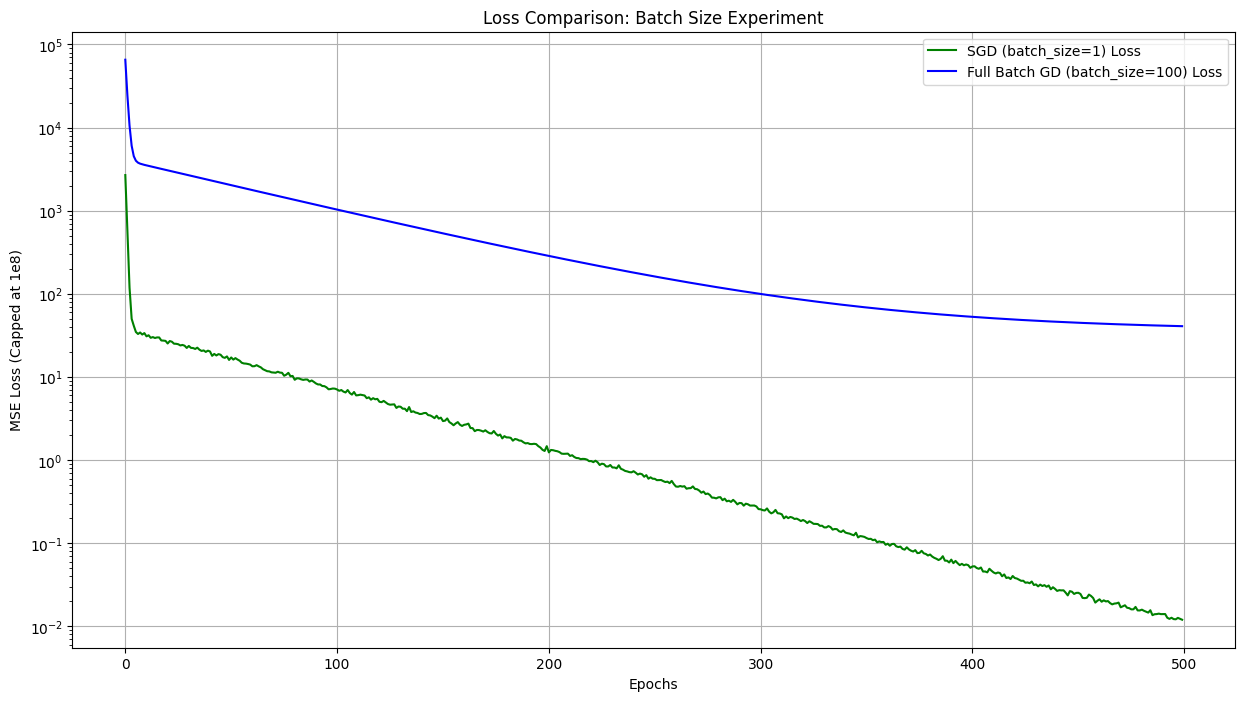


--- Analysis of Batch Size Experiment ---
**batch_size = 1 (Stochastic Gradient Descent - SGD):**
  When batch_size is 1, the model updates its weights after processing each individual data point. This introduces significant noise into the loss curve, making it very 'jagged'. While the updates are frequent, the direction of the gradient is less accurate, which can sometimes help escape local minima but can also lead to slower overall convergence or oscillations around the minimum. SGD is generally much faster per update step compared to Full Batch GD, especially with large datasets, but it might require more epochs to converge smoothly.

**batch_size = 100 (Full Batch Gradient Descent):**
  When batch_size is 100 (which is the size of our entire dataset), the algorithm computes the gradient using all data points before making a single weight update per epoch. This results in a very smooth loss curve, as the gradient is a precise average over the entire dataset. It offers a stable conv

In [25]:
#5.Experiment with batch size:

epochs_batch_size_exp = 500
lr_batch_size_exp = 0.0001

# --- Experiment with batch_size = 1 (Stochastic Gradient Descent) ---
print(f"\nRunning Mini-Batch GD with batch_size = 1 (SGD), LR={lr_batch_size_exp}, Epochs={epochs_batch_size_exp}")
MGD_sgd = mini_batch_gradient_descent(epochs=epochs_batch_size_exp, lr=lr_batch_size_exp, batch_size=1)
print(f"  SGD Final Loss: {MGD_sgd[0]:.4f}")
print(f"  SGD Final Coefficients: {MGD_sgd[1]}")

# --- Experiment with batch_size = 100 (Full Batch Gradient Descent) ---
# Note: hundred_xs has 100 samples, so batch_size=100 is full batch.
print(f"\nRunning Mini-Batch GD with batch_size = 100 (Full Batch GD), LR={lr_batch_size_exp}, Epochs={epochs_batch_size_exp}")
MGD_full_batch = mini_batch_gradient_descent(epochs=epochs_batch_size_exp, lr=lr_batch_size_exp, batch_size=100)
print(f"  Full Batch GD Final Loss: {MGD_full_batch[0]:.4f}")
print(f"  Full Batch GD Final Coefficients: {MGD_full_batch[1]}")

# --- Plotting the loss curves for comparison ---
plt.figure(figsize=(15, 8))

# Cap the maximum loss for plotting to prevent issues with log scale
max_plot_loss_val = 1e8

# Process SGD losses
plot_losses_sgd = np.array(MGD_sgd[2])
plot_losses_sgd = plot_losses_sgd[np.isfinite(plot_losses_sgd)]
if len(plot_losses_sgd) > 0:
    plot_losses_sgd = np.minimum(plot_losses_sgd, max_plot_loss_val)
    plt.plot(plot_losses_sgd, 'g-', label='SGD (batch_size=1) Loss')

# Process Full Batch GD losses
plot_losses_full_batch = np.array(MGD_full_batch[2])
plot_losses_full_batch = plot_losses_full_batch[np.isfinite(plot_losses_full_batch)]
if len(plot_losses_full_batch) > 0:
    plot_losses_full_batch = np.minimum(plot_losses_full_batch, max_plot_loss_val)
    plt.plot(plot_losses_full_batch, 'b-', label='Full Batch GD (batch_size=100) Loss')

plt.title('Loss Comparison: Batch Size Experiment')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Capped at 1e8)')
plt.yscale('log') # Use log scale for y-axis
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Analysis of Batch Size Experiment ---")
print("**batch_size = 1 (Stochastic Gradient Descent - SGD):**")
print("  When batch_size is 1, the model updates its weights after processing each individual data point. This introduces significant noise into the loss curve, making it very 'jagged'. While the updates are frequent, the direction of the gradient is less accurate, which can sometimes help escape local minima but can also lead to slower overall convergence or oscillations around the minimum. SGD is generally much faster per update step compared to Full Batch GD, especially with large datasets, but it might require more epochs to converge smoothly.")

print("\n**batch_size = 100 (Full Batch Gradient Descent):**")
print("  When batch_size is 100 (which is the size of our entire dataset), the algorithm computes the gradient using all data points before making a single weight update per epoch. This results in a very smooth loss curve, as the gradient is a precise average over the entire dataset. It offers a stable convergence path. However, computing the gradient over the entire dataset in each step is computationally expensive, especially for very large datasets, making each epoch slower compared to SGD or mini-batch GD. In this small-scale example, it might converge very effectively due to the small, convex problem.")

Initial random coefficients (from previous execution): (-7, 8, -5)

Running Gradient Descent with Momentum (LR=0.0001, Beta=0.9, Epochs=3000)
  Final Loss with Momentum: 24.5376
  Final Coefficients with Momentum: (np.float64(2.1281588762415007), np.float64(-2.9863100106443095), np.float64(-2.7082284715219664))


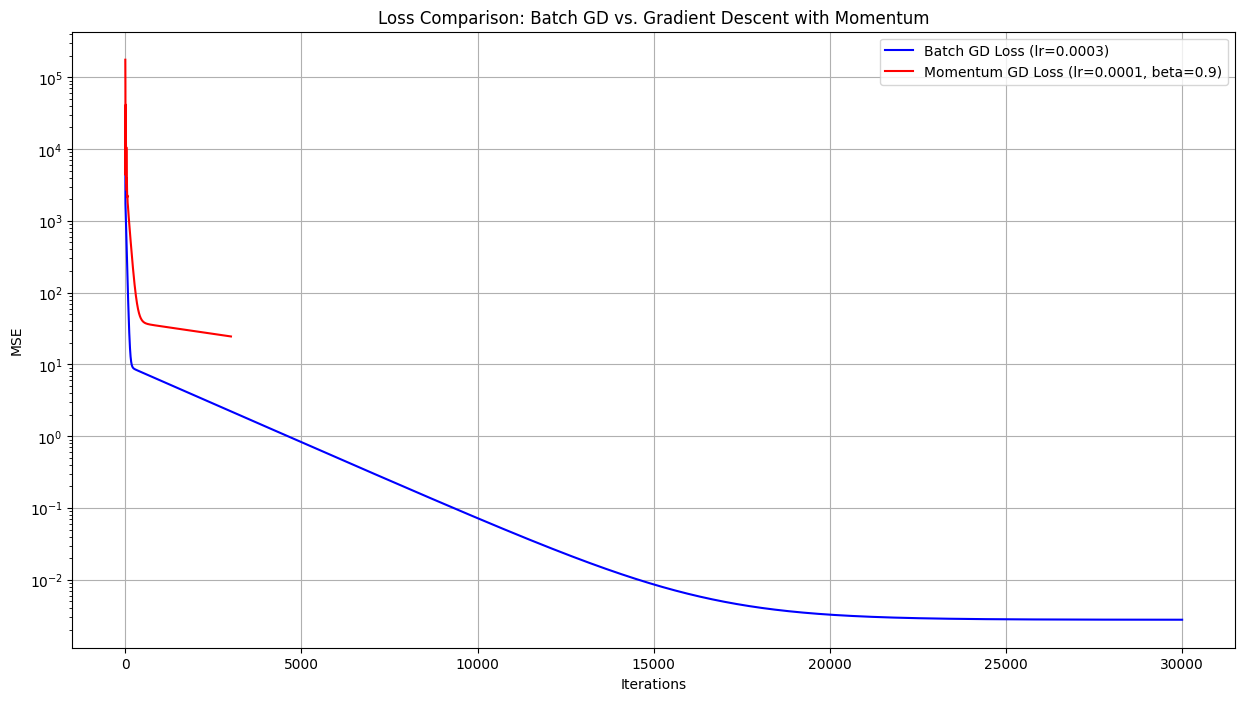

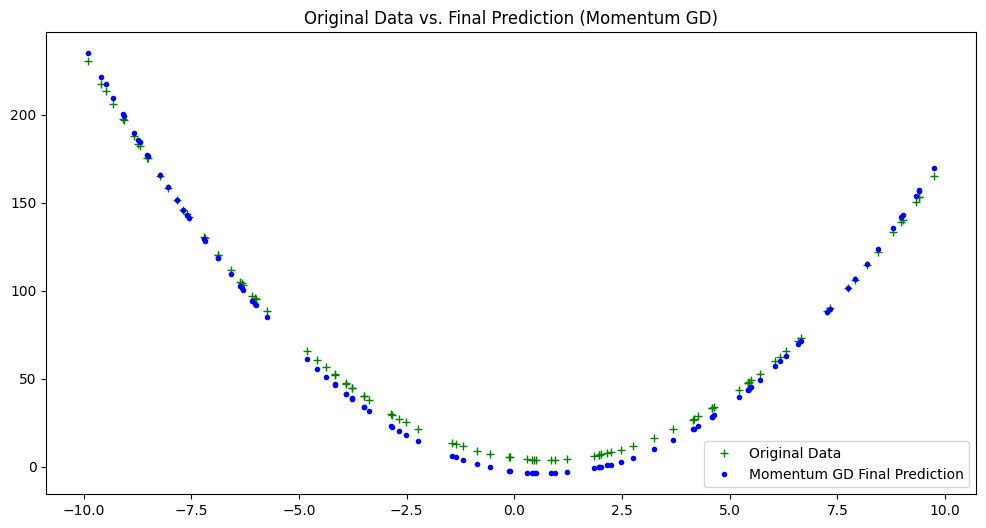

In [27]:
# 6. Research Gradient Descent with Momentum:(Example)

import numpy as np
import matplotlib.pyplot as plt

# Re-use/Define necessary functions and data from previous cells for self-containment
# Assuming eval_2nd_degree, loss_mse, calc_gradient_2nd_poly_for_GD, hundred_xs, ys are already defined.
# If not, they would need to be re-defined here or imported.

# We'll use the 'xs' and 'ys' that were generated for the y = 2x^2 - 3x + 5 polynomial
# from the 'Experiment with the learning rate' section, as that's the latest data context.
# Make sure these are the correct global variables or pass them explicitly if re-running.

# Assuming hundred_xs and ys are from the 'Change the polynomial' section
# For reproducibility, let's explicitly use the data generated for TARGET_COEFFS_FOR_GA_DEMO
# from the Gradient Ascent section, which used hundred_xs and added jitter.

# Ensure these variables are available. If not, the preceding cells should be run or their definitions copied.
# from previous cells to make this cell self-contained.
# For this example, we assume hundred_xs and ys are correctly set up by previous runs.

def gradient_descent_with_momentum(initial_coeffs, epochs, lr, beta, inputs_x, outputs_y):
    """
    Performs Gradient Descent with Momentum for a second degree polynomial.

    Args:
        initial_coeffs: Initial coefficients (a, b, c).
        epochs: Number of iterations.
        lr: Learning rate.
        beta: Momentum coefficient.
        inputs_x: x input datapoints.
        outputs_y: actual y output points.

    Returns: Tuple containing (final loss, final coefficients, list of losses, list of updated_y_bar values).
    """
    losses = []
    current_coeffs = list(initial_coeffs)
    velocity = [0.0, 0.0, 0.0] # Initialize velocity for a, b, c

    for i in range(epochs):
        # calc_gradient_2nd_poly_for_GD returns loss, new_coeffs, new_y_bar
        # We need the raw gradients, not the updated coeffs from inside that function.
        # So we'll adapt or re-implement gradient calculation directly.

        a_s = []
        b_s = []
        c_s = []

        y_bars = eval_2nd_degree(tuple(current_coeffs), inputs_x)

        for x, y, y_bar in list(zip(inputs_x, outputs_y, y_bars)):    # take tuple of (x datapoint, actual y label, predicted y label)
            x_squared = x ** 2
            partial_a = x_squared * (y - y_bar)
            a_s.append(partial_a)
            partial_b = x * (y - y_bar)
            b_s.append(partial_b)
            partial_c = (y - y_bar)
            c_s.append(partial_c)

        n = len(inputs_x)

        # These are the actual gradients of the MSE loss function w.r.t. a, b, c
        gradient_a = (-2 / n) * sum(a_s)
        gradient_b = (-2 / n) * sum(b_s)
        gradient_c = (-2 / n) * sum(c_s)

        gradients = [gradient_a, gradient_b, gradient_c]

        # Update velocity
        for j in range(len(gradients)):
            velocity[j] = beta * velocity[j] + (1 - beta) * gradients[j]

        # Update coefficients using velocity
        for j in range(len(current_coeffs)):
            current_coeffs[j] = current_coeffs[j] - lr * velocity[j]

        # Calculate loss with the new coefficients
        new_y_bar = eval_2nd_degree(tuple(current_coeffs), inputs_x)
        current_loss = loss_mse(outputs_y, new_y_bar)
        losses.append(current_loss)

        # Check for NaN or Inf loss and break if it occurs
        if not np.isfinite(current_loss):
            print(f"  Warning: Loss became non-finite at epoch {i+1}. Stopping early.")
            # Return a non-finite loss, current coefficients, and empty y_bar/losses to indicate failure
            return float('inf'), tuple(current_coeffs), [], []

    final_y_bar = eval_2nd_degree(tuple(current_coeffs), inputs_x)
    return losses[-1], tuple(current_coeffs), losses, final_y_bar

# --- Demonstration ---
print(f"Initial random coefficients (from previous execution): {rand_coeffs}")

# Parameters for Momentum GD
momentum_epochs = 3000
momentum_lr = 0.0001 # A learning rate that showed good convergence for Batch GD
beta_value = 0.9 # Common momentum coefficient

print(f"\nRunning Gradient Descent with Momentum (LR={momentum_lr}, Beta={beta_value}, Epochs={momentum_epochs})")

momentum_final_loss, momentum_final_coeffs, momentum_losses, momentum_final_y_bar = \
    gradient_descent_with_momentum(rand_coeffs, momentum_epochs, momentum_lr, beta_value, hundred_xs, ys)

print(f"  Final Loss with Momentum: {momentum_final_loss:.4f}")
print(f"  Final Coefficients with Momentum: {momentum_final_coeffs}")

# --- Plotting Loss Curves for Comparison (Batch GD vs. Momentum GD) ---
plt.figure(figsize=(15, 8))

# Batch GD Loss (from previous run, assuming GD[3] is available)
if 'GD' in globals() and len(GD) > 3:
    plt.plot(GD[3], 'b-', label='Batch GD Loss (lr=0.0003)') # Using a common lr for Batch GD
else:
    print("Warning: Batch GD results not found for comparison. Please run the Batch GD cell first if you want to see the comparison.")

# Momentum GD Loss
plt.plot(momentum_losses, 'r-', label=f'Momentum GD Loss (lr={momentum_lr}, beta={beta_value})')

plt.title('Loss Comparison: Batch GD vs. Gradient Descent with Momentum')
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.yscale('log') # Use log scale for y-axis to better visualize differences
plt.legend()
plt.grid(True)
plt.show()

# Plotting original data vs. final prediction from Momentum GD
plt.figure(figsize=(12, 6))
plt.plot(hundred_xs, ys, 'g+', label = 'Original Data')
plt.plot(hundred_xs, momentum_final_y_bar, 'b.', label = 'Momentum GD Final Prediction')
plt.title('Original Data vs. Final Prediction (Momentum GD)')
plt.legend(loc="lower right")
plt.show()


## 6. Research Gradient Descent with Momentum:

**Gradient Descent with Momentum** is an optimization algorithm designed to accelerate the training of neural networks (and other models optimized with gradient descent). It addresses some of the challenges of standard (Stochastic) Gradient Descent, particularly when dealing with noisy gradients or navigating flat regions and local minima in the loss landscape.

### What is Gradient Descent with Momentum?

Standard Gradient Descent updates parameters in the direction opposite to the current gradient. Momentum introduces a "velocity" term to these updates. Instead of just relying on the current gradient, it also considers the direction of previous updates. This is analogous to a ball rolling down a hill: it gains momentum, meaning it continues to roll in a certain direction even if the slope temporarily flattens or has small bumps.

The update rule for Gradient Descent with Momentum typically looks like this:

1.  **Calculate velocity:** $v_{t+1} = \beta v_t + (1 - \beta) \nabla J(w_t)$
2.  **Update weights:** $w_{t+1} = w_t - \eta v_{t+1}$

Where:
*   $w_t$ are the weights at time step $t$.
*   $\nabla J(w_t)$ is the gradient of the loss function with respect to the weights $w_t$.
*   $\eta$ (eta) is the learning rate.
*   $v_t$ is the velocity vector at time step $t$.
*   $\beta$ (beta) is the momentum coefficient (a hyperparameter, typically set to a value like 0.9). It determines how much of the previous velocity is retained.

### How it helps with Convergence Speed:

1.  **Accelerated Convergence in Consistent Directions:** When gradients consistently point in the same direction (e.g., in a long, shallow valley in the loss landscape), momentum builds up. This allows the optimizer to take larger steps in that consistent direction, speeding up convergence compared to standard GD, which might take many small, hesitant steps.
2.  **Overcoming Shallow Local Minima/Plateaus:** Momentum can help the optimizer "roll past" small humps or flat regions that might trap standard Gradient Descent. The accumulated velocity from previous steps can push it out of these suboptimal areas towards deeper minima.

### How it helps with Stability, especially with Noisy Gradients from Mini-Batch GD:

1.  **Dampening Oscillations:** In Mini-Batch GD, especially with a high learning rate, gradients can be noisy. This noise often causes updates to oscillate back and forth across a narrow valley in the loss landscape, slowing down convergence. Momentum helps by averaging out these noisy gradients over time. If a noisy gradient points in a slightly different direction for a few steps, the built-up momentum in the consistent direction will largely override these momentary deviations, leading to a smoother optimization path.
2.  **Reducing Variance in Updates:** By incorporating past gradients, momentum effectively smooths the update direction. This reduces the variance in parameter updates that can be caused by the stochasticity of mini-batch sampling. Less variance means a more stable and predictable path towards the minimum.
3.  **Allowing Larger Learning Rates:** Because momentum dampens oscillations and smooths updates, it often allows for the use of slightly larger learning rates without causing divergence. This can further accelerate convergence.

In essence, Gradient Descent with Momentum adds a form of inertia to the optimization process, making it more resilient to noisy gradients and more efficient at navigating complex loss landscapes.

## **Additional Critical Thinking Questions**

1. You are doing full batch gradient descent using the entire training set. Is it necessary to shuffle the training data? Explain your
answer.

2. You would like to train a dog/cat image classifier using mini-batch gradient
descent. You have already split your dataset into train, dev and test sets. The classes
are balanced. You realize that within the training set, the images are ordered in such a
way that all the dog images come first and all the cat images come after. A friend tells
you: ”you absolutely need to shuffle your training set before the training procedure.”
Is your friend right? Explain.

3. Our loss function for this quadratic regression problem is convex, meaning it has only one global minimum. Can you think of a scenario or a type of model where the loss function might have many local minima? How would that make training with gradient descent more challenging?

### **Answers to Critical Thinking Questions**

1. No, it is not necessary to shuffle the training data for Batch Gradient Descent. In each step, the gradient is calculated by summing the contributions from every single data point in the training set. Since addition is commutative, the order in which you sum up these contributions does not change the final gradient value. Therefore, shuffling the data will have no effect on the training trajectory.

2. Yes, your friend is absolutely right. In Mini-Batch Gradient Descent, the model updates its weights after seeing each small batch. If the data is ordered, the first several batches will consist only of dog images. The model will start to learn that everything is a dog and will adjust its weights heavily towards that prediction. Then, suddenly, it will start seeing batches of only cat images. It will have to drastically shift its weights to unlearn what it just learned and start classifying cats. This will cause the training process to be highly unstable and inefficient. By shuffling the data at the start of each epoch, every mini-batch will likely contain a random mix of dogs and cats, providing a much more stable and representative gradient for each update step.

3. Deep neural networks are a prime example of models with highly non-convex loss functions, which can have many local minima. A local minimum is a point that is lower than its immediate neighbors but is not the lowest possible point in the entire landscape. This makes training challenging because Gradient Descent is a "greedy" algorithm—it only looks for the downhill direction locally. It might descend into a local minimum and get "stuck" there, thinking it has found the best solution, even though a much better solution (the global minimum) exists elsewhere. Techniques like using a smaller learning rate, momentum, or using SGD (whose noise can help "bounce" out of shallow local minima) are used to mitigate this problem.